# Blackjack custom Gymnasium environment game

Blackjack: [Jakub Łabuz](https://github.com/jakseluz)\
tests and report: [Maciej Maj](https://github.com/mmaj1)

### 1) Basic environment usage

#### Define the environment

In [1]:
import gymnasium as gym
import blackjack_env
import time

env = gym.make("blackjack_env/Blackjack4game-v0", render_mode="terminal")
obs, info = env.reset()
print(info)
time.sleep(5)
env.close()

{'action_mask': array([1, 1, 1, 0, 0], dtype=int8), 'deck_status': 48, 'player_cards': [6, 4], 'dealer_cards': [9, 10], 'taken_action': None}


#### Check its correctness

In [2]:
# check_env uses random actions and fails with action-masked envs
obs, info = env.reset()
action = next(i for i, allowed in enumerate(info["action_mask"]) if allowed)
obs, reward, terminated, truncated, info = env.step(action)
print("step ok", reward, terminated, truncated)
env.close()

step ok 1.5 True False


#### Run a random game

In [ ]:
import gymnasium as gym
import blackjack_env
import time

env = gym.make("blackjack_env/Blackjack4game-v0", render_mode="human")
done = False
obs, info = env.reset()
while not done:
    action = env.action_space.sample()
    while info["action_mask"][action] == 0:
        action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    time.sleep(3)
    if done:
        print(info)
        print(f"Reward: {reward}")

time.sleep(7)
env.close()

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


{'action_mask': array([0, 1, 0, 0, 0], dtype=int8), 'deck_status': 47, 'player_cards': [4, 8, 10], 'dealer_cards': [7, 10], 'taken_action': np.int64(1)}
Reward: -1.0


#### Run a random game but with only allowed actions

In [4]:
import gymnasium as gym
import blackjack_env
import time

env = gym.make("blackjack_env/Blackjack4game-v0", render_mode="human")
done = False
obs, info = env.reset()
while not done:
    action = env.action_space.sample()
    while info["action_mask"][action] == 0:
        action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    time.sleep(3)
    if done:
        print(info)
        print(f"Reward: {reward}")


time.sleep(7)
env.close()

{'action_mask': array([0, 1, 0, 0, 0], dtype=int8), 'deck_status': 44, 'player_cards': [4, 9, 10], 'dealer_cards': [4, 2, 6, 11, 4], 'taken_action': np.int64(2)}
Reward: -2.0


### 2) Simple Q-learning agent

#### Run Q-learning agent

In [6]:
import gymnasium as gym
import blackjack_env
from blackjack_env.agent_utils.q_learning import q_learning

env = gym.make("blackjack_env/Blackjack4game-v0", render_mode="terminal")
q_table, rewards_history = q_learning(env, num_episodes=10000)

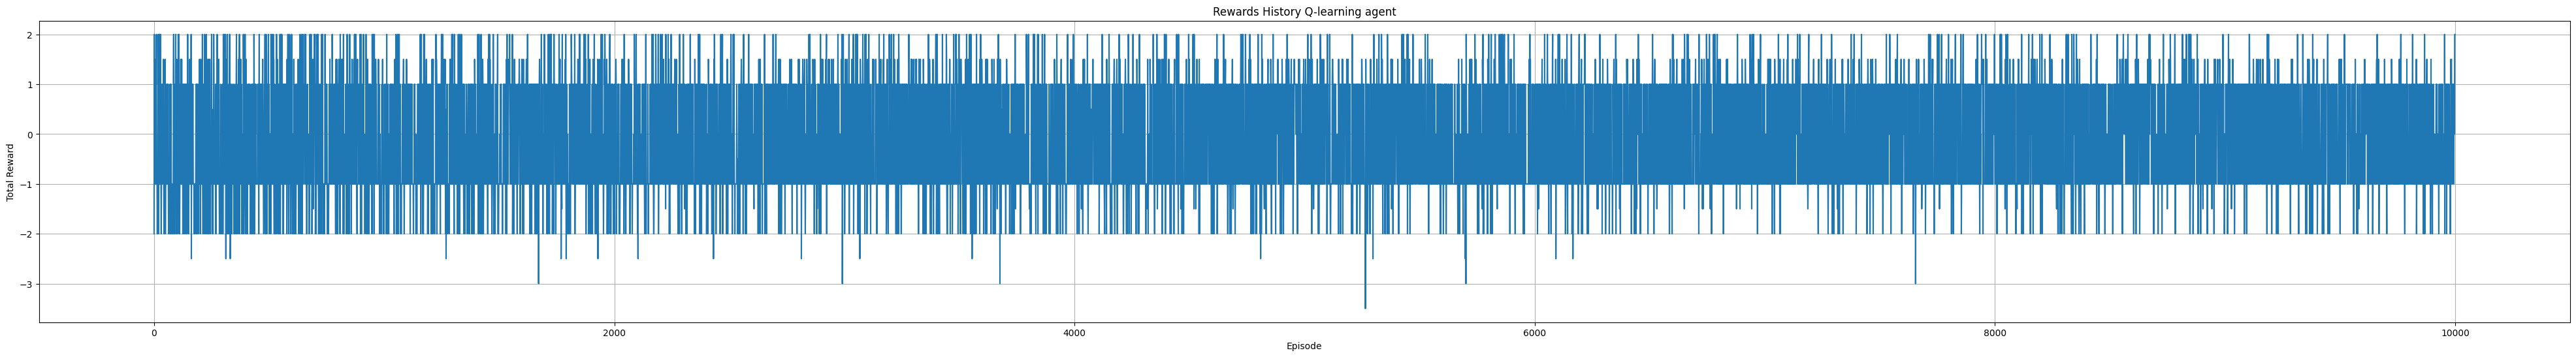

In [7]:
from blackjack_env.agent_utils.q_learning import plot_rewards_history

plot_rewards_history(rewards_history)

### 3) Real tests

#### Run a more proper learning with intelligence mode
In this mode, agent has an additional observation value which indicates what cards (low - high value) have been used so far.

In [ ]:
import gymnasium as gym
from blackjack_env.agent_utils.q_learning import q_learning
import numpy as np

env_intel = gym.make("blackjack_env/Blackjack4game-v0", intelligence_mode=True)

NUM_EPISODES = 1_000_000
alpha = 0.05
epsilon_decay = 0.99999

q_table_intel, history_intel = q_learning(
    env_intel, num_episodes=NUM_EPISODES, alpha=alpha, epsilon_decay=epsilon_decay
)

print("Trening zakończony.")

Trening zakończony.


#### Run the learning evaluation

In [ ]:
import numpy as np
from blackjack_env.agent_utils.q_learning import get_state_index


def evaluate_intelligence(env, q_table, n_episodes=20000):
    results = {"positive_count": [], "negative_count": [], "neutral_count": []}

    for _ in range(n_episodes):
        obs, info = env.reset()
        count = obs["running_count"]
        done = False

        while not done:
            state_idx = get_state_index(obs, has_running_count=True)
            action_mask = info["action_mask"].astype(bool)
            allowed_actions = np.flatnonzero(action_mask)
            action = allowed_actions[np.argmax(q_table[state_idx][allowed_actions])]
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        category = "neutral_count"
        if count > 2:
            category = "positive_count"
        elif count < -2:
            category = "negative_count"

        results[category].append(reward)

    for cat, rewards in results.items():
        win_rate = (np.array(rewards) > 0).mean()
        print(f"Kategoria: {cat} | Win Rate: {win_rate:.2%} | Liczba gier: {len(rewards)}")


evaluate_intelligence(env_intel, q_table_intel)

Kategoria: positive_count | Win Rate: 45.14% | Liczba gier: 988
Kategoria: negative_count | Win Rate: 67.50% | Liczba gier: 1006
Kategoria: neutral_count | Win Rate: 40.20% | Liczba gier: 18006


#### Plot the learning curve

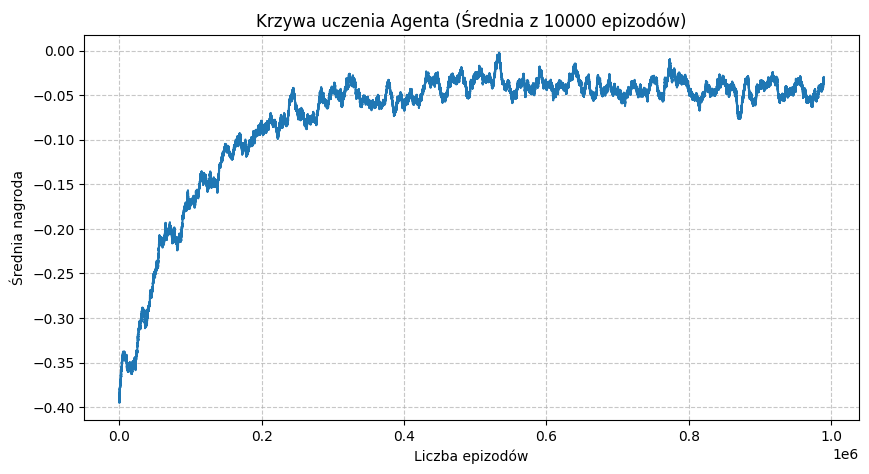

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_learning_curve(rewards_history, window_size=5000):
    moving_avg = np.convolve(rewards_history, np.ones(window_size) / window_size, mode="valid")

    plt.figure(figsize=(10, 5))
    plt.plot(moving_avg, color="#1f77b4", linewidth=1.5)
    plt.title(f"Krzywa uczenia Agenta (Średnia z {window_size} epizodów)")
    plt.xlabel("Liczba epizodów")
    plt.ylabel("Średnia nagroda")
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.savefig("learning_curve.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_learning_curve(history_intel, window_size=10000)

#### Other indicators

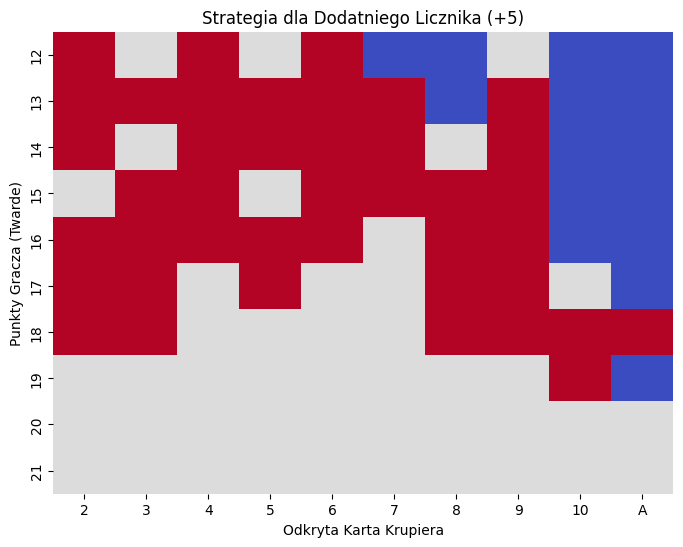

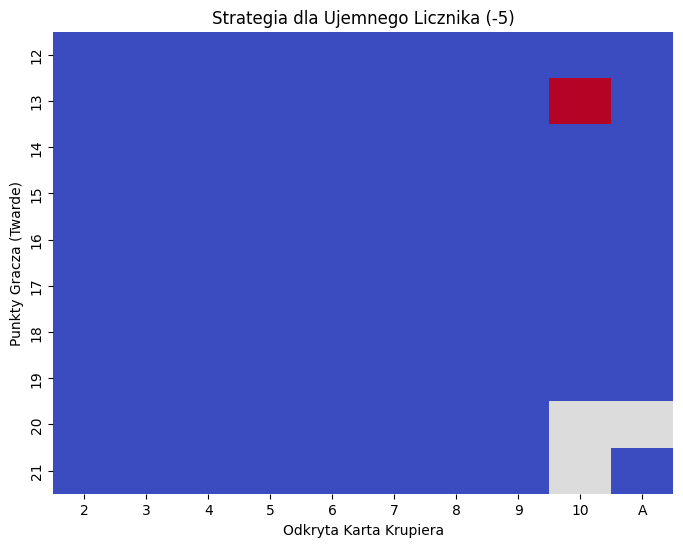

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_policy_heatmap(q_table, running_count_val, title, filename):
    policy_grid = np.zeros((10, 10))

    for p_points in range(12, 22):
        for d_card in range(2, 12):
            state = {
                "player_points": p_points,
                "not_used_ace": 0,
                "dealer_card": d_card,
                "running_count": running_count_val,
            }

            state_idx = get_state_index(state, has_running_count=True)

            # Zakładamy najpopularniejsze akcje: 0=HIT, 1=STAND, 2=DOUBLE
            # Wybieramy najlepszą spośród pierwszych trzech
            best_action = np.argmax(q_table[state_idx][:3])
            policy_grid[p_points - 12, d_card - 2] = best_action

    plt.figure(figsize=(8, 6))
    # Tworzenie mapy ciepła z własnymi etykietami dla ładnego wyglądu
    ax = sns.heatmap(
        policy_grid,
        annot=True,
        cmap="coolwarm",
        cbar=False,
        xticklabels=[str(i) for i in range(2, 11)] + ["A"],
        yticklabels=range(12, 22),
    )

    plt.title(title)
    plt.xlabel("Odkryta Karta Krupiera")
    plt.ylabel("Punkty Gracza (Twarde)")

    # 0 = Hit, 1 = Stand, 2 = Double
    for t in ax.texts:
        if t.get_text() == "0.0":
            t.set_text("Hit")
        elif t.get_text() == "1.0":
            t.set_text("Stand")
        elif t.get_text() == "2.0":
            t.set_text("Double")
        else:
            t.set_text("")

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_policy_heatmap(
    q_table_intel, running_count_val=5, title="Strategia dla Dodatniego Licznika (+5)", filename="policy_positive.png"
)

plot_policy_heatmap(
    q_table_intel, running_count_val=-5, title="Strategia dla Ujemnego Licznika (-5)", filename="policy_negative.png"
)